# **Aula Guiada - Aula 9**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ry4n-felinto/impytech_2026/blob/main/arquivos/aula_09/aula09_notebook_guiado.ipynb)

 - **Professor:** Pedro Alberti 
    - al.pedro.alberti@impatech.edu.br

 - **Monitores:**
   - Bianca Zavadisk
      - al.bianca.abreu@impatech.edu.br
   - Bruno Pereira
      - al.bruno.paula@impatech.edu.br
   - Gustavo Cardoso
      - al.gustavo.cardoso@impatech.edu.br
   - Cristiane Sampaio
      - al.cristiane.sampaio@impatech.edu.br
 
 ## **Machine Learning: da Regressão Linear aos Conceitos Fundamentais**

---

### O que você vai aprender hoje

**Parte 1 — Generalização: treino, teste e overfitting**
- Por que separar dados em treino e teste
- Overfitting e underfitting

**Parte 2 — Quando a regressão linear não é suficiente (e o que usar no lugar)**
- Relação não-linear → regressão polinomial e árvore de decisão
- Alvo categórico → regressão logística
- Outliers fortes → regressão robusta
- Poucos dados / muitas variáveis → regularização (Ridge e Lasso)
- Escolha de hiperparâmetros
- Extrapolação → um cuidado que nenhum modelo resolve sozinho

**Parte 3 — Generalizando: o mapa do Machine Learning**
- Regressão vs. classificação, supervisionado vs. não supervisionado
- O fluxo geral de qualquer projeto de ML


---
# Parte 1 — Generalização: treino, teste e overfitting

Se o objetivo do ML é **prever dados novos**, não faz sentido avaliar o modelo só nos dados que ele já viu — seria como aplicar a prova para o aluno **depois** de dar o gabarito.

## 1.1 Separando treino e teste

A prática padrão em ML é separar os dados em dois grupos **antes** de treinar:

- **Treino:** os dados que o modelo usa para "aprender" (ajustar $b_0$ e $b_1$).
- **Teste:** dados que ficam de fora do treino, guardados só para avaliar o modelo no final — simulando pacientes novos.

O `scikit-learn` faz essa divisão com `train_test_split`:


In [1]:
from sklearn.model_selection import train_test_split

# Vamos simular uma corte um pouco maior de pacientes
np.random.seed(42)
n_pacientes = 30
idade_sim = np.random.uniform(20, 80, n_pacientes) 
pressao_sim = 90 + 0.8 * idade_sim + np.random.normal(0, 6, n_pacientes)  # tendência + ruído biológico

X_sim = idade_sim.reshape(-1, 1)
y_sim = pressao_sim

# test_size=0.3 -> 30% dos pacientes reservados só para teste
X_treino_sim, X_teste_sim, y_treino_sim, y_teste_sim = train_test_split(
    X_sim, y_sim, test_size=0.3, random_state=42
)

print("Pacientes no treino:", len(X_treino_sim))
print("Pacientes no teste: ", len(X_teste_sim))

plt.scatter(X_treino_sim, y_treino_sim, color="tab:blue", label="Treino")
plt.scatter(X_teste_sim, y_teste_sim, color="tab:orange", label="Teste (o modelo não vê estes!)")
plt.xlabel("Idade (anos)")
plt.ylabel("Pressão sistólica (mmHg)")
plt.legend()
plt.title("Separando pacientes em treino e teste")
plt.show()


NameError: name 'np' is not defined

In [ ]:
# Treinamos usando SOMENTE os dados de treino
modelo_sim = LinearRegression()
modelo_sim.fit(X_treino_sim, y_treino_sim)

# Avaliamos nos dois conjuntos
erro_treino = mean_squared_error(y_treino_sim, modelo_sim.predict(X_treino_sim))
erro_teste  = mean_squared_error(y_teste_sim,  modelo_sim.predict(X_teste_sim))

print(f"Erro (MSE) no treino: {erro_treino:.2f}")
print(f"Erro (MSE) no teste:  {erro_teste:.2f}")


Erro (MSE) no treino: 20.21
Erro (MSE) no teste:  34.03


Os dois erros são parecidos — bom sinal! O modelo **generaliza**: não decorou os pacientes de treino, aprendeu um padrão que também vale para pacientes novos.

Nem sempre é assim. Quando o erro de teste é **muito maior** que o de treino, temos um dos problemas mais importantes de ML: **overfitting**.

## 1.2 Overfitting e underfitting

- **Underfitting** (modelo simples demais): nem consegue capturar o padrão presente no treino. Erro alto no treino **e** no teste.
- **Overfitting** (modelo complexo demais): "decora" o treino, inclusive o ruído. Erro baixo no treino, mas erro alto no teste.

Vamos visualizar isso com um exemplo clássico em farmacologia: a resposta a uma dose de medicamento costuma **saturar** em doses altas (não é uma reta!) — um cenário ótimo para ilustrar o problema.


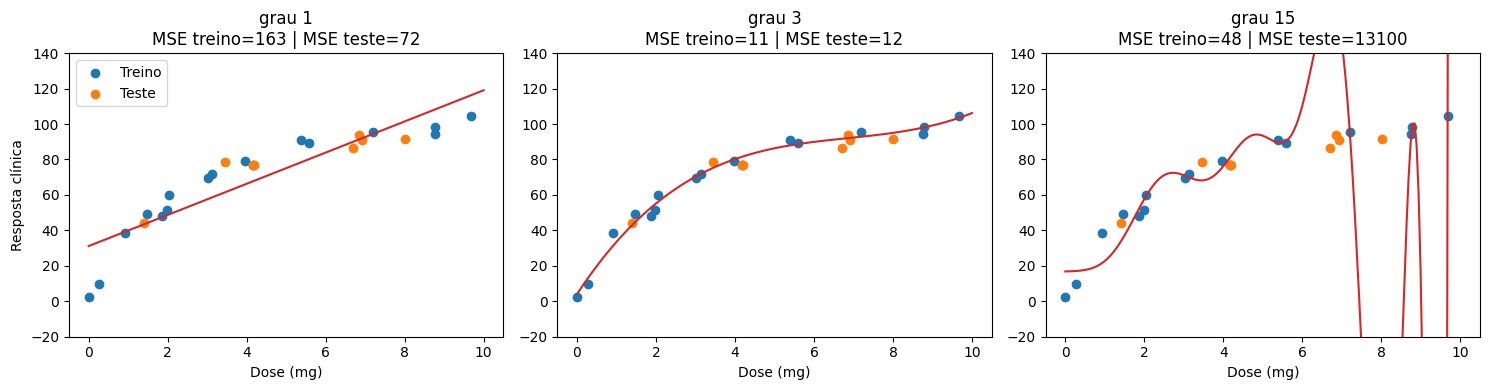

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(1)
n = 25
dose = np.sort(np.random.uniform(0, 10, n))
resposta = 100 * (1 - np.exp(-0.4 * dose)) + np.random.normal(0, 4, n)  # saturação + ruído

X_dose = dose.reshape(-1, 1)
X_tr_dose, X_te_dose, y_tr_dose, y_te_dose = train_test_split(
    X_dose, resposta, test_size=0.3, random_state=1
)

graus = [1, 3, 15]
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
dose_plot = np.linspace(0, 10, 200).reshape(-1, 1)

for eixo, grau in zip(eixos, graus):
    modelo_poly = make_pipeline(PolynomialFeatures(grau), LinearRegression())
    modelo_poly.fit(X_tr_dose, y_tr_dose)

    erro_tr = mean_squared_error(y_tr_dose, modelo_poly.predict(X_tr_dose))
    erro_te = mean_squared_error(y_te_dose, modelo_poly.predict(X_te_dose))

    eixo.scatter(X_tr_dose, y_tr_dose, color="tab:blue", label="Treino")
    eixo.scatter(X_te_dose, y_te_dose, color="tab:orange", label="Teste")
    eixo.plot(dose_plot, modelo_poly.predict(dose_plot), color="tab:red")
    eixo.set_ylim(-20, 140)
    eixo.set_title(f"grau {grau}\nMSE treino={erro_tr:.0f} | MSE teste={erro_te:.0f}")
    eixo.set_xlabel("Dose (mg)")

eixos[0].set_ylabel("Resposta clínica")
eixos[0].legend()
plt.tight_layout()
plt.show()


Observem o padrão:

- **Grau 1 (reta):** simples demais para a curva de saturação — erro alto em treino **e** teste. **Underfitting**.
- **Grau 3:** captura bem a forma da curva, com erro baixo e parecido em treino e teste. Bom equilíbrio.
- **Grau 15:** faz curvas bizarras para passar exatamente pelos pontos de treino (erro de treino baixíssimo), mas erra feio no teste. **Overfitting**.

Vamos guardar esse exemplo de dose-resposta — na Parte 3 vamos voltar a ele para comparar diferentes formas de lidar com uma relação não-linear.

### ✏️ Exercício 1

Você tem medidas de glicemia de jejum (mg/dL) e HbA1c (%, exame que reflete a glicemia média dos últimos 3 meses) de 20 pacientes:

```python
np.random.seed(7)
glicemia = np.random.uniform(70, 200, 20)
hba1c = 4 + 0.03 * glicemia + np.random.normal(0, 0.4, 20)
```

**🎯 Objetivo:**
1. Separe os dados em treino (80%) e teste (20%) com `train_test_split` (use `random_state=7`).
2. Treine um `LinearRegression` para prever `hba1c` a partir de `glicemia`, usando **só o treino**.
3. Calcule o MSE no treino e no teste e imprima os dois valores.
4. Em um comentário, escreva se o modelo parece estar generalizando bem.


In [ ]:
np.random.seed(7)
glicemia = np.random.uniform(70, 200, 20)
hba1c = 4 + 0.03 * glicemia + np.random.normal(0, 0.4, 20)

# Seu código aqui




---
# Parte 2 — Quando a regressão linear não é suficiente (e o que usar no lugar)

Regressão linear é simples e interpretável, mas isso vem com pressupostos — ignorá-los leva a conclusões clínicas erradas. Vamos ver, um a um, os principais motivos para **não** usar regressão linear pura — e, em cada caso, qual ferramenta de ML usar no lugar.

Duas seções mais adiante vamos precisar de um dataset com **várias variáveis clínicas** prevendo a glicemia — vamos criá-lo já, de uma vez:


In [ ]:
# Dataset simulado com várias variáveis correlacionadas prevendo a glicemia,
# mas com poucos pacientes (situação clássica de risco de overfitting)
np.random.seed(0)
n = 12
idade_ex = np.random.randint(30, 70, n)
imc_ex = np.random.uniform(20, 35, n)
colesterol_ex = np.random.uniform(150, 260, n)
triglicerideos_ex = np.random.uniform(80, 220, n)

X_multi = np.column_stack([idade_ex, imc_ex, colesterol_ex, triglicerideos_ex])
glicemia_ex = 60 + 0.6*idade_ex + 1.2*imc_ex + 0.05*colesterol_ex + np.random.normal(0, 5, n)
variaveis = ["idade", "imc", "colesterol", "triglicerídeos"]

print("Formato de X_multi (pacientes x variáveis):", X_multi.shape)


Formato de X_multi (pacientes x variáveis): (12, 4)


## 2.1 A relação não é linear → árvores de decisão

Lembram da curva de dose-resposta da Parte 2? Uma reta (grau 1) claramente **não** capturava aquela saturação, e o polinômio de grau 3 resolveu o problema — mas exigiu que **nós** escolhêssemos o grau certo. Vamos conhecer agora uma família de modelos que lida com não-linearidade **sem precisar escolher grau nenhum**: as **árvores de decisão**. Como é um dos modelos mais usados (e mais visuais) em ML, vamos entender bem como ela funciona por dentro.

### 2.1.1 Como uma árvore "pensa"

Uma árvore de decisão para regressão aprende, sozinha, uma sequência de perguntas do tipo *"dose ≤ 4.2?"*. Cada pergunta divide os pacientes em dois grupos, e o processo se repete dentro de cada grupo. No final, cada "folha" da árvore prevê simplesmente a **média** dos valores de $y$ dos pacientes que caíram ali.

Para decidir **qual** pergunta fazer em cada etapa, o algoritmo testa várias variáveis e vários limiares (*thresholds*) possíveis, e escolhe a divisão que **minimiza o erro combinado** dos dois grupos resultantes:

$$
MSE_{divisão} = \frac{n_{esq}}{n}\, MSE_{esq} + \frac{n_{dir}}{n}\, MSE_{dir}
$$

Ou seja: a mesma função de custo (MSE) da Parte 2 — só que, em vez de ajustar uma reta, a árvore procura o **melhor corte** para separar os dados em grupos mais homogêneos.


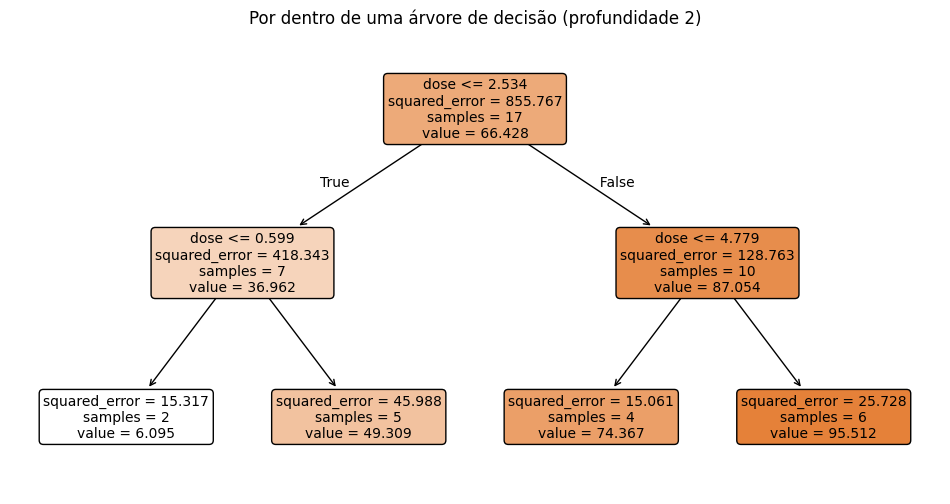

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score

# Uma árvore rasa (profundidade 2) é fácil de visualizar por completo
arvore_rasa = DecisionTreeRegressor(max_depth=2, random_state=0)
arvore_rasa.fit(X_tr_dose, y_tr_dose)

plt.figure(figsize=(12, 6))
plot_tree(arvore_rasa, feature_names=["dose"], filled=True, rounded=True, fontsize=10)
plt.title("Por dentro de uma árvore de decisão (profundidade 2)")
plt.show()


Cada caixa é um **nó**: mostra a pergunta feita (ex: `dose <= 4.978`), o `squared_error` (o MSE dentro daquele grupo), o `samples` (quantos pacientes de treino caíram ali) e o `value` (a previsão — a média de $y$ do grupo). As caixas finais (sem pergunta) são as **folhas**: é ali que a árvore efetivamente "decide" o valor previsto. Quanto mais escura a cor, maior o valor previsto naquele nó.

### 2.1.2 Como a árvore "corta" o espaço, passo a passo

Cada nível extra de profundidade permite mais um corte, refinando a previsão. Vamos ver isso ganhar forma visualmente, comparando profundidades 1, 2, 3 e 6:


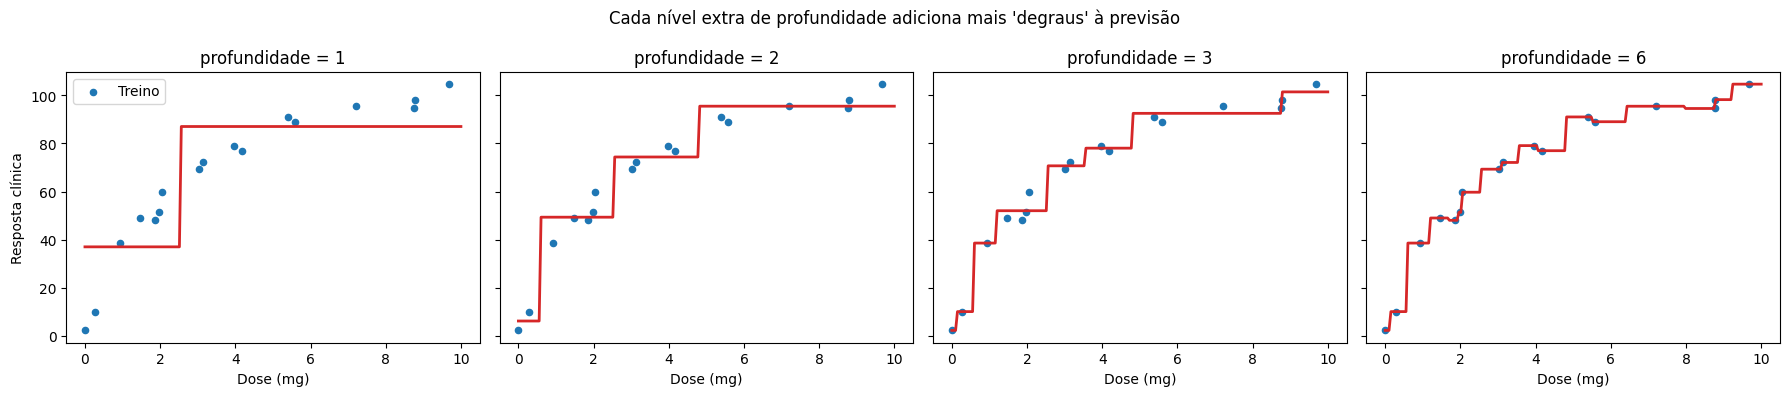

In [ ]:
profundidades = [1, 2, 3, 6]
fig, eixos = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for eixo, prof in zip(eixos, profundidades):
    arv = DecisionTreeRegressor(max_depth=prof, random_state=0).fit(X_tr_dose, y_tr_dose)
    eixo.scatter(X_tr_dose, y_tr_dose, color="tab:blue", s=20, label="Treino")
    eixo.plot(dose_plot, arv.predict(dose_plot), color="tab:red", linewidth=2)
    eixo.set_title(f"profundidade = {prof}")
    eixo.set_xlabel("Dose (mg)")

eixos[0].set_ylabel("Resposta clínica")
eixos[0].legend()
plt.suptitle("Cada nível extra de profundidade adiciona mais 'degraus' à previsão")
plt.tight_layout()
plt.show()


Com profundidade 1, a árvore só consegue fazer **um** corte (dois grupos). Com profundidade 6, ela já faz cortes tão finos que a "escada" quase parece uma curva suave — mas também já começa a reagir a detalhes específicos do treino, e não só ao padrão geral. Isso deveria soar familiar: é o mesmo dilema do grau do polinômio na Parte 2!

### 2.1.3 Profundidade da árvore = complexidade do modelo

Assim como o grau do polinômio, a **profundidade máxima** (`max_depth`) controla o quanto a árvore pode se complicar. Vamos medir o erro em treino e teste para várias profundidades, do mesmo jeito que fizemos com o MSE na Parte 2:


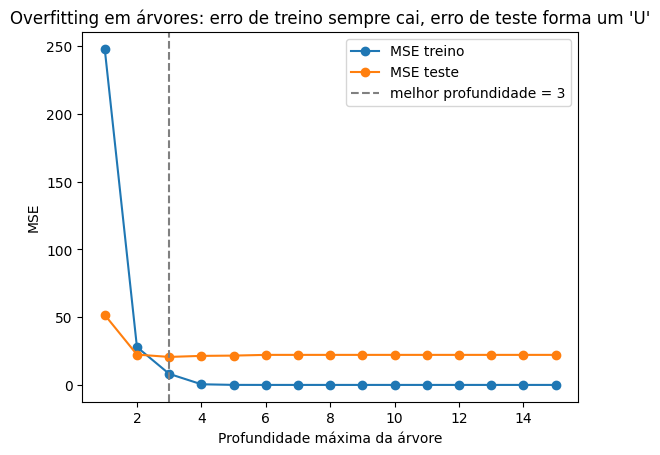

In [ ]:
profundidades_teste = range(1, 16)
erro_treino_arvore, erro_teste_arvore = [], []

for prof in profundidades_teste:
    arv = DecisionTreeRegressor(max_depth=prof, random_state=0).fit(X_tr_dose, y_tr_dose)
    erro_treino_arvore.append(mean_squared_error(y_tr_dose, arv.predict(X_tr_dose)))
    erro_teste_arvore.append(mean_squared_error(y_te_dose, arv.predict(X_te_dose)))

melhor_prof = list(profundidades_teste)[np.argmin(erro_teste_arvore)]

plt.plot(profundidades_teste, erro_treino_arvore, marker="o", label="MSE treino")
plt.plot(profundidades_teste, erro_teste_arvore, marker="o", label="MSE teste")
plt.axvline(melhor_prof, color="gray", linestyle="--", label=f"melhor profundidade = {melhor_prof}")
plt.xlabel("Profundidade máxima da árvore")
plt.ylabel("MSE")
plt.legend()
plt.title("Overfitting em árvores: erro de treino sempre cai, erro de teste forma um 'U'")
plt.show()


O erro de **treino** só diminui conforme a árvore cresce (ela sempre consegue decorar mais). O erro de **teste**, porém, melhora até um ponto e depois **piora** — o clássico formato de "U" do overfitting. A melhor profundidade é a que minimiza o erro no teste, não a maior profundidade possível.

### 2.1.4 Comparando árvore, polinômio e reta

Agora com uma profundidade escolhida de forma criteriosa (e não "no chute"), vamos comparar as três abordagens na mesma curva de dose-resposta:


Linear (grau 1)              -> R² no teste: 0.678
Polinomial (grau 3)          -> R² no teste: 0.946
Árvore (profundidade 3)      -> R² no teste: 0.908


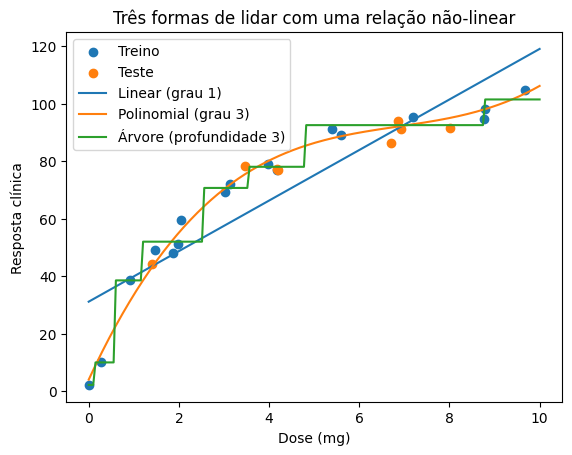

In [ ]:
modelo_linear_dose = LinearRegression().fit(X_tr_dose, y_tr_dose)
modelo_poly3_dose  = make_pipeline(PolynomialFeatures(3), LinearRegression()).fit(X_tr_dose, y_tr_dose)
modelo_arvore_dose = DecisionTreeRegressor(max_depth=melhor_prof, random_state=0).fit(X_tr_dose, y_tr_dose)

modelos_dose = [("Linear (grau 1)", modelo_linear_dose),
                ("Polinomial (grau 3)", modelo_poly3_dose),
                (f"Árvore (profundidade {melhor_prof})", modelo_arvore_dose)]

for nome, modelo_dose in modelos_dose:
    r2_teste = r2_score(y_te_dose, modelo_dose.predict(X_te_dose))
    print(f"{nome:28s} -> R² no teste: {r2_teste:.3f}")

plt.scatter(X_tr_dose, y_tr_dose, color="tab:blue", label="Treino")
plt.scatter(X_te_dose, y_te_dose, color="tab:orange", label="Teste")
for nome, modelo_dose in modelos_dose:
    plt.plot(dose_plot, modelo_dose.predict(dose_plot), label=nome)
plt.xlabel("Dose (mg)")
plt.ylabel("Resposta clínica")
plt.legend()
plt.title("Três formas de lidar com uma relação não-linear")
plt.show()


Tanto a regressão polinomial quanto a árvore conseguem seguir a curva de saturação — cada uma "desenhando" a curva à sua maneira (uma equação suave vs. uma escada de degraus). A regressão linear pura fica muito atrás das duas.

### 2.1.5 Bônus: quais variáveis a árvore considera mais importantes?

Quando há várias variáveis (como no exemplo de glicemia da Parte 3.4, com idade, IMC, colesterol e triglicerídeos), a árvore também nos diz **quanto cada variável contribuiu** para reduzir o erro — o chamado `feature_importances_`:


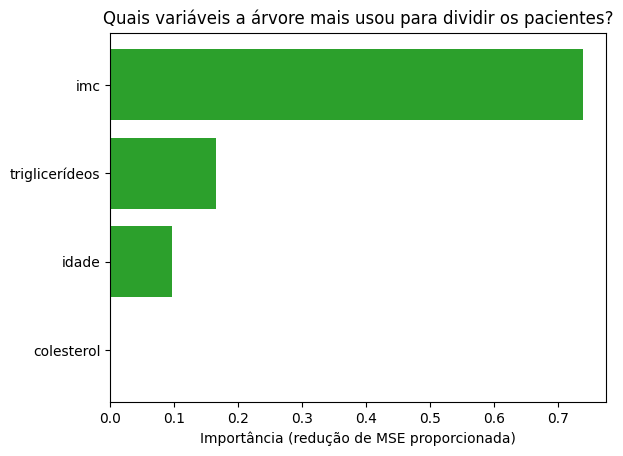

In [ ]:
arvore_multi = DecisionTreeRegressor(max_depth=3, random_state=0)
arvore_multi.fit(X_multi, glicemia_ex)

importancias = pd.Series(arvore_multi.feature_importances_, index=variaveis).sort_values()

plt.barh(list(importancias.index), list(importancias.values), color="tab:green")
plt.xlabel("Importância (redução de MSE proporcionada)")
plt.title("Quais variáveis a árvore mais usou para dividir os pacientes?")
plt.show()


> 💡 **Vantagens das árvores:** capturam não-linearidades automaticamente, não exigem escolher um grau polinomial, lidam bem com variáveis em escalas diferentes, e o diagrama da árvore é fácil de explicar para um público não-técnico ("se a dose for maior que X, a resposta é Y").
>
> ⚠️ **Cuidados:** uma árvore sozinha tende a *overfitar* se deixada crescer livremente (controle a profundidade!), e pequenas mudanças nos dados podem gerar árvores bem diferentes. Por isso, na prática, é comum combinar **centenas de árvores** em conjunto (florestas aleatórias, *gradient boosting*).

> 💡 Regra prática geral: sempre olhe o gráfico de dispersão **antes** de ajustar uma reta. O olho humano ainda é ótimo para perceber quando uma relação claramente não é linear.


## 2.2 O alvo é categórico → regressão logística

Prever "tem diabetes" ou "não tem diabetes" (sim/não) **não** é tarefa para regressão linear — a saída de uma reta pode ser qualquer número (inclusive -3 ou 158), o que não faz sentido para uma probabilidade ou categoria.

A ferramenta certa aqui é a **regressão logística** — que, apesar do nome, é um algoritmo de **classificação**: ela prevê a **probabilidade** de um paciente pertencer a uma categoria, sempre entre 0 e 1.

Em vez de uma reta, a regressão logística passa a combinação linear $b_0 + b_1 x$ por uma **função sigmoide**, que "espreme" qualquer número real para o intervalo entre 0 e 1:

$$
p = \frac{1}{1 + e^{-(b_0 + b_1 x)}}
$$

E a função de custo também muda: em vez do MSE, usa-se o **log loss** (ou *cross-entropy*), que penaliza fortemente previsões confiantes e erradas:

$$
\text{Log Loss} = -\frac{1}{n}\sum_{i=1}^n \Big[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\Big]
$$

O espírito continua o mesmo da Parte 2.3: "treinar" é **minimizar uma função de custo** — só que aqui a função de custo é o log loss, não o MSE.


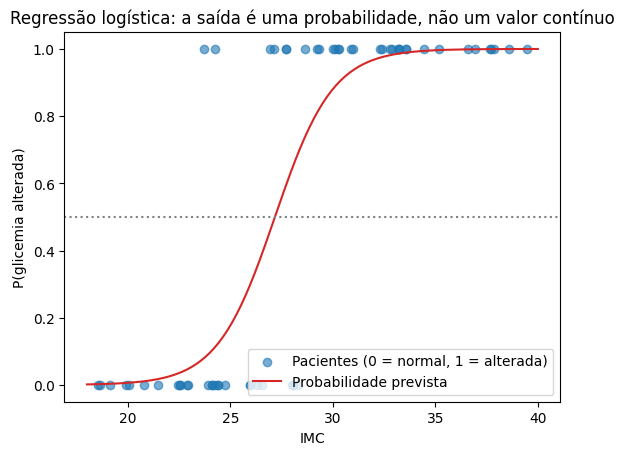

In [ ]:
from sklearn.linear_model import LogisticRegression

np.random.seed(3)
n = 60
imc = np.random.uniform(18, 40, n)
prob_alterada = 1 / (1 + np.exp(-(imc - 27) * 0.5))  # probabilidade cresce com o IMC
glicemia_alterada = (np.random.uniform(0, 1, n) < prob_alterada).astype(int)

X_imc = imc.reshape(-1, 1)

modelo_log = LogisticRegression()
modelo_log.fit(X_imc, glicemia_alterada)

imc_plot = np.linspace(18, 40, 200).reshape(-1, 1)
prob_prevista = modelo_log.predict_proba(imc_plot)[:, 1]

plt.scatter(imc, glicemia_alterada, color="tab:blue", alpha=0.6, label="Pacientes (0 = normal, 1 = alterada)")
plt.plot(imc_plot, prob_prevista, color="tab:red", label="Probabilidade prevista")
plt.axhline(0.5, color="gray", linestyle=":")
plt.xlabel("IMC")
plt.ylabel("P(glicemia alterada)")
plt.legend()
plt.title("Regressão logística: a saída é uma probabilidade, não um valor contínuo")
plt.show()


Note a diferença estrutural: em vez de uma reta, temos uma curva em "S" (a função logística) que sempre fica entre 0 e 1. Se a probabilidade prevista for maior que 0.5, classificamos o paciente como "glicemia alterada".

| | Regressão | Classificação |
|---|---|---|
| O que prevê | um número contínuo | uma categoria (ou a probabilidade de cada categoria) |
| Exemplo clínico | dose ideal, pressão, tempo de internação | tem/não tem a doença, tipo de tumor |
| Algoritmo visto hoje | `LinearRegression` | `LogisticRegression` |


## 2.3 Outliers fortes → regressão robusta

Um único paciente com valor muito fora do padrão pode "puxar" a reta inteira e distorcer a conclusão para todos os outros — a `LinearRegression` comum é bastante sensível a isso, porque o MSE **eleva o erro ao quadrado**, dando peso enorme a pontos muito distantes.

Uma alternativa é o `HuberRegressor`, um modelo **robusto** que trata erros grandes de forma mais branda (menos sensível a outliers):


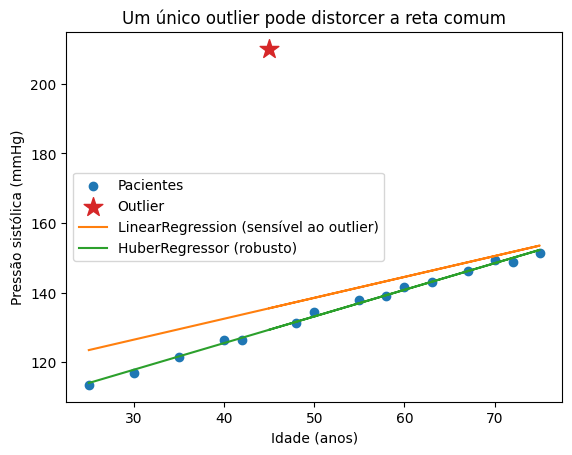

In [ ]:
from sklearn.linear_model import HuberRegressor

# Reaproveitando idade x pressão sistólica, mas com um paciente "extremo" adicionado
idades_out = np.append(idades, 45)
pressao_out = np.append(pressao_sistolica, 210)   # um valor clinicamente muito improvável

X_out = idades_out.reshape(-1, 1)
y_out = pressao_out

modelo_comum = LinearRegression().fit(X_out, y_out)
modelo_robusto = HuberRegressor().fit(X_out, y_out)

plt.scatter(idades_out[:-1], pressao_out[:-1], color="tab:blue", label="Pacientes")
plt.scatter(idades_out[-1], pressao_out[-1], color="tab:red", marker="*", s=200, label="Outlier")
plt.plot(idades_out, modelo_comum.predict(X_out), color="tab:orange", label="LinearRegression (sensível ao outlier)")
plt.plot(idades_out, modelo_robusto.predict(X_out), color="tab:green", label="HuberRegressor (robusto)")
plt.xlabel("Idade (anos)")
plt.ylabel("Pressão sistólica (mmHg)")
plt.legend()
plt.title("Um único outlier pode distorcer a reta comum")
plt.show()


Repare como a reta comum (laranja) se inclina na direção do outlier, enquanto a reta robusta (verde) continua próxima do padrão da maioria dos pacientes. Isso não significa "ignorar" o outlier sem investigar — ele pode ser um erro de digitação **ou** um caso clínico genuinamente importante. Mas, para efeitos de modelagem geral, um modelo robusto evita que um único ponto domine a conclusão.


## 2.4 Poucos dados, muitas variáveis → regularização (Ridge e Lasso)

Quando usamos **várias variáveis** ao mesmo tempo para prever algo (por exemplo, prever a glicemia usando idade, IMC, colesterol e triglicerídeos juntos), corremos o risco de **overfitting** — o mesmo problema da Parte 2, só que causado por excesso de variáveis em vez de excesso de grau polinomial. Isso é mais comum quando temos poucos pacientes e muitas variáveis.

A **regularização** resolve isso adicionando uma penalidade aos coeficientes grandes, forçando o modelo a ser mais "simples" e generalizar melhor:

- **Ridge (penalidade L2):** encolhe todos os coeficientes de forma suave, mas raramente os zera e tem formula fechada.
- **Lasso (penalidade L1):** pode zerar completamente os coeficientes menos importantes — funcionando como uma **seleção automática de variáveis**, mas não tem formula fechada.

```python
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)
```

O parâmetro `alpha` controla a força da penalidade: `alpha=0` equivale à regressão linear comum; quanto maior o `alpha`, mais os coeficientes são "encolhidos". Formalmente, os dois modelos minimizam o MSE **mais** uma penalidade:

$$
\text{Custo}_{Ridge} = \underbrace{\frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2}_{MSE} \;+\; \alpha \sum_{j} b_j^2
\qquad\qquad
\text{Custo}_{Lasso} = \underbrace{\frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2}_{MSE} \;+\; \alpha \sum_{j} |b_j|
$$

A diferença entre elevar ao quadrado ($b_j^2$, Ridge) ou usar o valor absoluto ($|b_j|$, Lasso) é sutil na fórmula, mas tem um efeito prático grande: a penalidade do Lasso consegue empurrar coeficientes **exatamente** a zero; a do Ridge só os encolhe, sem nunca chegar a zero.


In [ ]:
from sklearn.linear_model import Ridge, Lasso

linear_multi = LinearRegression().fit(X_multi, glicemia_ex)
ridge_multi = Ridge(alpha=10).fit(X_multi, glicemia_ex)
lasso_multi = Lasso(alpha=1.0).fit(X_multi, glicemia_ex)

print(f"{'variável':15s}{'Linear':>10s}{'Ridge':>10s}{'Lasso':>10s}")
for nome, c_lin, c_rid, c_las in zip(variaveis, linear_multi.coef_, ridge_multi.coef_, lasso_multi.coef_):
    print(f"{nome:15s}{c_lin:10.2f}{c_rid:10.2f}{c_las:10.2f}")


variável           Linear     Ridge     Lasso
idade                0.56      0.55      0.55
imc                  2.08      1.90      1.98
colesterol           0.05      0.06      0.05
triglicerídeos       0.03      0.04      0.03


Nenhuma opção é "a certa" — a escolha depende do problema: use Lasso quando suspeitar que só algumas variáveis realmente importam; use Ridge quando acreditar que todas contribuem um pouco.

### O caminho de regularização: o que acontece se variarmos o `alpha`?

Uma visualização clássica em ML é o **caminho de regularização**: como cada coeficiente muda conforme aumentamos `alpha` de quase zero até um valor bem alto.


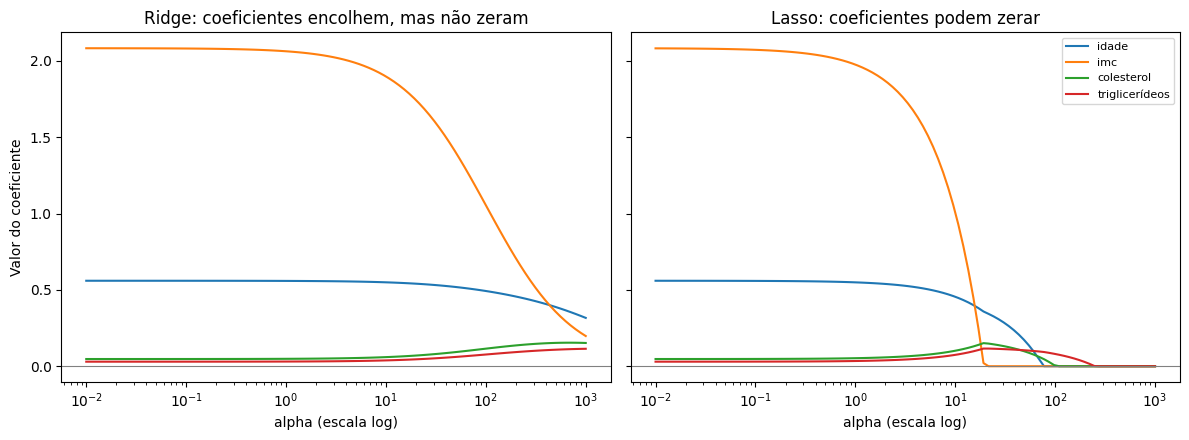

In [ ]:
alphas = np.logspace(-2, 3, 100)

coefs_ridge = [Ridge(alpha=a).fit(X_multi, glicemia_ex).coef_ for a in alphas]
coefs_lasso = [Lasso(alpha=a, max_iter=10000).fit(X_multi, glicemia_ex).coef_ for a in alphas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for i, nome in enumerate(variaveis):
    ax1.plot(alphas, [c[i] for c in coefs_ridge], label=nome)
    ax2.plot(alphas, [c[i] for c in coefs_lasso], label=nome)

for ax, titulo in [(ax1, "Ridge: coeficientes encolhem, mas não zeram"),
                    (ax2, "Lasso: coeficientes podem zerar")]:
    ax.set_xscale("log")
    ax.set_xlabel("alpha (escala log)")
    ax.set_title(titulo)
    ax.axhline(0, color="gray", linewidth=0.8)

ax1.set_ylabel("Valor do coeficiente")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()


No gráfico da esquerda (Ridge), as curvas se aproximam de zero conforme `alpha` cresce, mas nunca o alcançam de fato. No gráfico da direita (Lasso), várias curvas **encostam** em zero e ficam ali — exatamente a "seleção automática de variáveis" que mencionamos acima.


## 2.5 Escolha de hiperparâmetros: validação cruzada (*cross-validation*)

Antes de treinar o modelo definitivo, muitas vezes precisamos fazer escolhas que **não são parâmetros aprendidos automaticamente pelos dados**, mas decisões nossas sobre a estrutura do modelo — os chamados **hiperparâmetros**: a profundidade máxima de uma árvore (`max_depth`), o grau do polinômio, ou a força da penalização em Ridge/Lasso (`alpha`).

Por que não simplesmente testar vários valores e ficar com o que dá o melhor $R^2$ no conjunto de **teste**? Porque, se usarmos o teste repetidas vezes para escolher hiperparâmetros, ele deixa de servir como medida honesta de generalização — estaríamos, na prática, ajustando o modelo ao teste "pela porta dos fundos", e o desempenho observado ali deixaria de representar pacientes realmente novos.

A solução é a **validação cruzada em $k$ partes ($k$-fold cross-validation)**, aplicada **dentro do treino**:

1. Dividimos o conjunto de treino em $k$ partes ("*folds*") de tamanho parecido.
2. Em cada uma das $k$ rodadas, treinamos o modelo usando $k-1$ partes e avaliamos na parte restante (que não participou do treino naquela rodada).
3. Calculamos a média (e o desvio-padrão) do desempenho nas $k$ rodadas — uma estimativa mais estável do que usar uma única divisão treino/validação.

Repetimos esse processo para cada valor candidato do hiperparâmetro (por exemplo, cada `alpha`) e escolhemos o valor com melhor desempenho médio na validação cruzada. **Só então** o conjunto de teste é usado — uma única vez — para confirmar a generalização do modelo já finalizado.

No `scikit-learn`, isso pode ser feito manualmente com `KFold` + `cross_val_score`, ou de forma automática com `GridSearchCV`, que testa uma grade de hiperparâmetros e já devolve o melhor modelo, escolhido por validação cruzada.


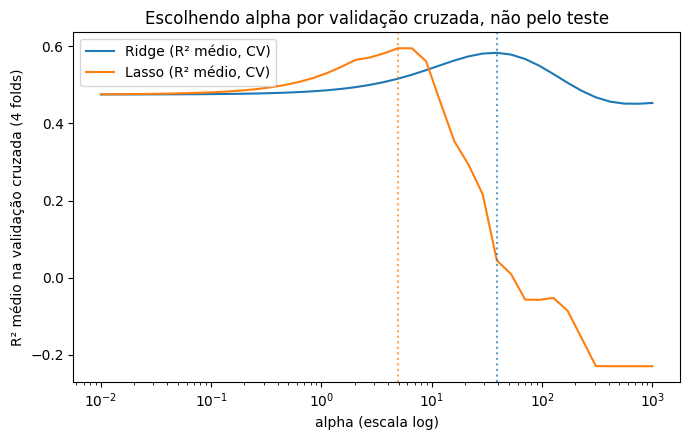

Melhor alpha (Ridge): 38.882  (R² CV = 0.583)
Melhor alpha (Lasso): 4.924  (R² CV = 0.595)


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

alphas = np.logspace(-2, 3, 40)
kf = KFold(n_splits=4, shuffle=True, random_state=0)

r2_ridge_cv = [cross_val_score(Ridge(alpha=a), X_multi, glicemia_ex, cv=kf, scoring="r2").mean()
               for a in alphas]
r2_lasso_cv = [cross_val_score(Lasso(alpha=a, max_iter=10000), X_multi, glicemia_ex, cv=kf, scoring="r2").mean()
               for a in alphas]

melhor_alpha_ridge = alphas[np.argmax(r2_ridge_cv)]
melhor_alpha_lasso = alphas[np.argmax(r2_lasso_cv)]

plt.figure(figsize=(7, 4.5))
plt.plot(alphas, r2_ridge_cv, label="Ridge (R² médio, CV)", color="tab:blue")
plt.plot(alphas, r2_lasso_cv, label="Lasso (R² médio, CV)", color="tab:orange")
plt.axvline(melhor_alpha_ridge, color="tab:blue", linestyle=":", alpha=0.7)
plt.axvline(melhor_alpha_lasso, color="tab:orange", linestyle=":", alpha=0.7)
plt.xscale("log")
plt.xlabel("alpha (escala log)")
plt.ylabel("R² médio na validação cruzada (4 folds)")
plt.title("Escolhendo alpha por validação cruzada, não pelo teste")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Melhor alpha (Ridge): {melhor_alpha_ridge:.3f}  (R² CV = {max(r2_ridge_cv):.3f})")
print(f"Melhor alpha (Lasso): {melhor_alpha_lasso:.3f}  (R² CV = {max(r2_lasso_cv):.3f})")


Repare o formato: o $R^2$ médio na validação cruzada sobe, atinge um pico e depois cai conforme `alpha` cresce demais — a penalização passa de "controla o overfitting" para "força demais os coeficientes para perto de zero" (*underfitting*). É o mesmo dilema viés-variância que vimos com o grau do polinômio e com a profundidade da árvore, agora aplicado à força da regularização. O pico de cada curva marca o `alpha` que a validação cruzada recomenda para aquele modelo.

> 💡 Na prática, raramente se escreve esse laço à mão: `GridSearchCV(Ridge(), param_grid={"alpha": alphas}, cv=4, scoring="r2")` faz a mesma busca automaticamente e já devolve o melhor modelo treinado, com `.best_params_` e `.best_score_`.


## 2.6 Extrapolação → um cuidado que nenhum modelo resolve sozinho

O modelo só é confiável **dentro** da faixa de dados observada. Se os dados de treino vão de 25 a 75 anos, usar o modelo para prever a pressão de um paciente de 2 anos é **extrapolar** — e isso vale para regressão linear, polinomial, árvore de decisão ou qualquer outro modelo: nenhum deles "sabe" o que acontece fora da região que observou, eles só extrapolam a tendência que aprenderam, às vezes de forma absurda.


In [ ]:
print("Faixa etária observada nos dados:", idades.min(), "a", idades.max(), "anos")

previsao_bebe = modelo.predict([[2]])[0]
previsao_idoso_extremo = modelo.predict([[150]])[0]
print(f"Previsão (extrapolada!) de pressão sistólica para 2 anos:   {previsao_bebe:.1f} mmHg")
print(f"Previsão (extrapolada!) de pressão sistólica para 150 anos: {previsao_idoso_extremo:.1f} mmHg")
print("Ambas as idades estão bem fora da faixa observada (25 a 75 anos) --")
print("o modelo simplesmente continua 'puxando a reta', sem saber que está extrapolando.")


Faixa etária observada nos dados: 25 a 75 anos
Previsão (extrapolada!) de pressão sistólica para 2 anos:   96.4 mmHg
Previsão (extrapolada!) de pressão sistólica para 150 anos: 209.6 mmHg
Ambas as idades estão bem fora da faixa observada (25 a 75 anos) --
o modelo simplesmente continua 'puxando a reta', sem saber que está extrapolando.


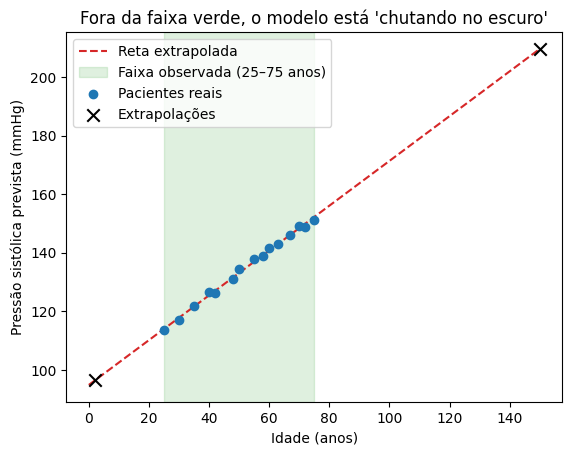

In [ ]:
idade_ampla = np.linspace(0, 150, 300)

plt.plot(idade_ampla, modelo.predict(idade_ampla.reshape(-1, 1)), color="tab:red", linestyle="--",
         label="Reta extrapolada")
plt.axvspan(idades.min(), idades.max(), color="tab:green", alpha=0.15, label="Faixa observada (25–75 anos)")
plt.scatter(idades, pressao_sistolica, color="tab:blue", zorder=3, label="Pacientes reais")
plt.scatter([2, 150], [previsao_bebe, previsao_idoso_extremo], color="black", marker="x", s=80,
            zorder=3, label="Extrapolações")
plt.xlabel("Idade (anos)")
plt.ylabel("Pressão sistólica prevista (mmHg)")
plt.legend()
plt.title("Fora da faixa verde, o modelo está 'chutando no escuro'")
plt.show()


---
## 2.7 Modelos paramétricos x não paramétricos

Depois de conhecer várias alternativas à regressão linear, vale organizar uma distinção que atravessa tudo o que vimos até aqui: **paramétrico x não paramétrico**. Não tem a ver com "ter ou não ter parâmetros" (todo modelo tem parâmetros internos) — tem a ver com **se assumimos, de antemão, uma forma fixa para a relação entre $x$ e $y$**.

- **Modelo paramétrico:** assumimos uma forma funcional fixa, descrita por um **número fixo** de parâmetros, escolhido *antes* de ver os dados. Os dados servem só para estimar os valores desses parâmetros. Regressão linear é o exemplo mais claro: decidimos de antemão que a relação é $y = b_0 + b_1 x$ — não importa se temos 20 ou 20.000 pacientes, continuamos estimando apenas dois números. Regressão logística, Ridge e Lasso também são paramétricos, pela mesma razão.

- **Modelo não paramétrico:** não assumimos uma forma fixa para a relação; a complexidade do modelo pode **crescer com a quantidade de dados**. Uma árvore de decisão não decide, antes de ver os dados, "vou ter exatamente 5 cortes" — o número de cortes (e a forma final da função aprendida) depende dos próprios dados. O mesmo vale para o KNN (*k-nearest neighbors*), que nem chega a resumir os dados em uma fórmula: para prever um paciente novo, ele olha diretamente para os pacientes mais parecidos no conjunto de treino.

| | Paramétrico | Não paramétrico |
|---|---|---|
| Forma da relação | fixada antes de ver os dados | aprendida a partir dos dados |
| Nº de "parâmetros" | fixo (ex: $b_0, b_1$) | cresce com a quantidade de dados |
| Exemplos vistos hoje | `LinearRegression`, `LogisticRegression`, `Ridge`, `Lasso`, `HuberRegressor` | `DecisionTreeRegressor`, KNN |
| Suposição sobre os dados | forte (ex: relação linear) | fraca — deixa os dados "falarem" |


### Flexibilidade x interpretabilidade

Essa distinção está diretamente ligada a um dos *trade-offs* mais importantes em Machine Learning:

- **Modelos paramétricos** costumam ser **mais interpretáveis**: o coeficiente $b_1$ tem um significado clínico direto ("a cada ano a mais de idade, a pressão sobe $b_1$ mmHg"). Em compensação, são **menos flexíveis**: se a suposição de forma estiver errada (ex: a relação real é uma curva de saturação, não uma reta), o modelo **erra sistematicamente**, não importa quantos dados você adicione — é o *underfitting* estrutural que vimos na Parte 3.1.

- **Modelos não paramétricos** costumam ser **mais flexíveis**: uma árvore suficientemente profunda, ou um KNN com poucos vizinhos, conseguem se ajustar a praticamente qualquer formato de relação presente nos dados. Em compensação, são **menos interpretáveis** ("por que o modelo previu esse valor?" pode não ter uma resposta simples de uma frase) e, sem cuidado (controlar `max_depth`, número de vizinhos, etc.), tendem a *overfitar* — é fácil demais "decorar" o treino.

> 💡 Não existe o lado "certo" do *trade-off* — existe o lado certo **para o seu problema**. Em um contexto clínico onde a decisão precisa ser explicada a um médico ou a um paciente, a interpretabilidade de um modelo paramétrico pode valer mais do que alguns pontos percentuais de $R^2$. Em um problema de previsão pura, onde só o desempenho importa, a flexibilidade de um modelo não paramétrico costuma vencer.

Vamos ver essa troca na prática, comparando um modelo paramétrico (regressão linear) com um não paramétrico (KNN) na mesma curva de dose-resposta da Parte 3.1:


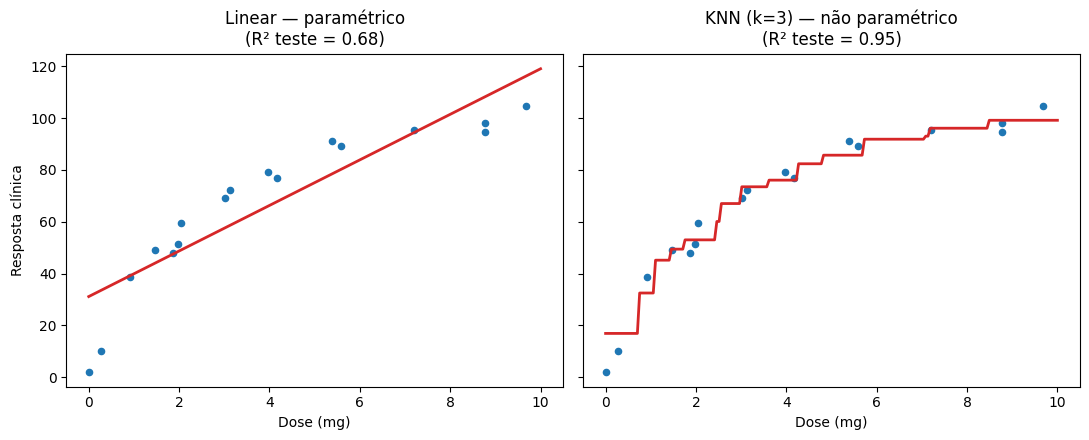

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

modelo_linear_par = LinearRegression().fit(X_tr_dose, y_tr_dose)
modelo_knn_naopar = KNeighborsRegressor(n_neighbors=3).fit(X_tr_dose, y_tr_dose)

r2_linear = r2_score(y_te_dose, modelo_linear_par.predict(X_te_dose))
r2_knn = r2_score(y_te_dose, modelo_knn_naopar.predict(X_te_dose))

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for eixo, (nome, modelo_dose_x, r2) in zip(
        eixos,
        [("Linear — paramétrico", modelo_linear_par, r2_linear),
         ("KNN (k=3) — não paramétrico", modelo_knn_naopar, r2_knn)]):
    eixo.scatter(X_tr_dose, y_tr_dose, color="tab:blue", s=20, label="Treino")
    eixo.plot(dose_plot, modelo_dose_x.predict(dose_plot), color="tab:red", linewidth=2)
    eixo.set_title(f"{nome}\n(R² teste = {r2:.2f})")
    eixo.set_xlabel("Dose (mg)")

eixos[0].set_ylabel("Resposta clínica")
plt.tight_layout()
plt.show()


A reta (paramétrica) é fácil de descrever em uma frase, mas não tem como acompanhar a curva de saturação — sua forma está travada antes mesmo de olhar para os dados. O KNN (não paramétrico) segue a curva de perto, à custa de virar uma "escada" mais difícil de resumir em poucas palavras — e mais sensível a como os vizinhos mais próximos de cada paciente se distribuem. Nenhum dos dois é "o melhor modelo de ML" em geral: a escolha depende de quanto você precisa explicar a previsão versus quanto você precisa que ela seja precisa.


> 💡 Resumo da Parte 2: para cada "não use regressão linear" existe uma ferramenta melhor — **exceto** para extrapolação, que é resolvida com bom senso (checar a faixa de dados) e não com um algoritmo diferente. A escolha de hiperparâmetros deve ser feita por validação cruzada, nunca espiando o teste; e, ao escolher entre as ferramentas, vale lembrar do equilíbrio entre modelos paramétricos (mais interpretáveis) e não paramétricos (mais flexíveis).

### ✏️ Exercício 2

Você tem a idade e quer prever se o paciente é **hipertenso** (1) ou **não hipertenso** (0):

```python
np.random.seed(9)
n = 50
idade_ex2 = np.random.uniform(20, 80, n)
prob_hipertensao = 1 / (1 + np.exp(-(idade_ex2 - 55) * 0.15))
hipertenso = (np.random.uniform(0, 1, n) < prob_hipertensao).astype(int)
```

**🎯 Objetivo:**
1. Esse é um problema de regressão ou de classificação? 
2. Treine um `LogisticRegression` para prever `hipertenso` a partir de `idade_ex2`.
3. Use `.predict_proba(...)` para prever a probabilidade de hipertensão de um paciente de 68 anos.


In [ ]:
np.random.seed(9)
n = 50
idade_ex2 = np.random.uniform(20, 80, n)
prob_hipertensao = 1 / (1 + np.exp(-(idade_ex2 - 55) * 0.15))
hipertenso = (np.random.uniform(0, 1, n) < prob_hipertensao).astype(int)

# Seu código aqui




---
# Parte 3 — Generalizando: o mapa do Machine Learning

Vimos, na prática, vários "sabores" de modelo: regressão linear, polinomial, árvore de decisão, logística, robusta, Ridge, Lasso. Vamos agora organizar tudo isso em um mapa conceitual mais amplo.

## 3.1 Regressão vs. classificação (recapitulando)

Como já vimos na seção 2.2: problemas de **regressão** preveem números contínuos; problemas de **classificação** preveem categorias. A maioria dos modelos de ML se encaixa em uma dessas duas famílias (com exceções, como veremos a seguir).

## 3.2 Aprendizado supervisionado vs. não supervisionado

Em tudo que vimos até agora, cada paciente tinha um **rótulo conhecido** — a pressão real, se a glicemia estava alterada. O modelo aprende comparando sua previsão com essa "resposta certa". Isso é **aprendizado supervisionado**.

Mas às vezes não temos rótulo nenhum — só queremos **descobrir padrões ou grupos** nos dados. Isso é **aprendizado não supervisionado**. Um exemplo comum em saúde: agrupar pacientes por perfil de biomarcadores, sem saber de antemão quantos "tipos" de paciente existem.


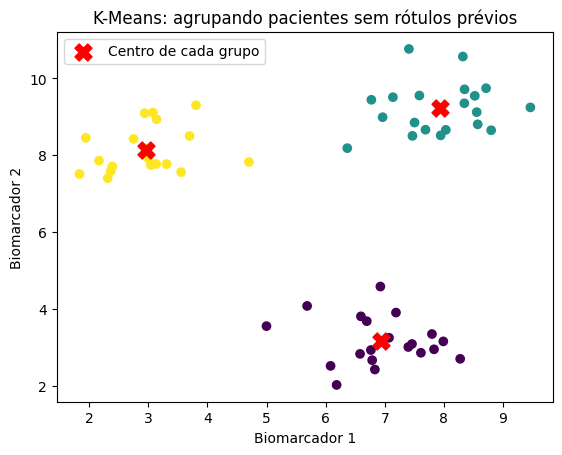

In [ ]:
from sklearn.cluster import KMeans

np.random.seed(5)
# Simulando dois biomarcadores para 3 perfis distintos de pacientes (sem rótulo!)
grupo_a = np.random.normal(loc=[3, 8], scale=0.7, size=(20, 2))
grupo_b = np.random.normal(loc=[7, 3], scale=0.7, size=(20, 2))
grupo_c = np.random.normal(loc=[8, 9], scale=0.7, size=(20, 2))
biomarcadores = np.vstack([grupo_a, grupo_b, grupo_c])

# O algoritmo não recebe nenhuma informação sobre os grupos reais!
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
clusters_encontrados = kmeans.fit_predict(biomarcadores)

plt.scatter(biomarcadores[:, 0], biomarcadores[:, 1], c=clusters_encontrados, cmap="viridis")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color="red", marker="X", s=150, label="Centro de cada grupo")
plt.xlabel("Biomarcador 1")
plt.ylabel("Biomarcador 2")
plt.title("K-Means: agrupando pacientes sem rótulos prévios")
plt.legend()
plt.show()


O algoritmo `KMeans` não sabia, a priori, que existiam três perfis — ele **descobriu** essa estrutura só olhando para a distribuição dos pontos. Esse tipo de análise é muito usado para, por exemplo, identificar subtipos de uma doença a partir de dados de expressão gênica ou de exames.

| | Supervisionado | Não supervisionado |
|---|---|---|
| Tem rótulo/resposta certa? | Sim | Não |
| Objetivo | prever um valor ou categoria conhecida | encontrar estrutura/agrupamentos nos dados |
| Algoritmos vistos hoje | `LinearRegression`, `LogisticRegression`, árvores, Ridge/Lasso, Huber | `KMeans` |


## 3.3 O fluxo geral de um projeto de Machine Learning

Independentemente do algoritmo — regressão linear, árvore de decisão, K-Means, ou modelos bem mais sofisticados como florestas aleatórias e redes neurais — todo projeto supervisionado de ML segue, no fundo, o mesmo roteiro:

1. **Coletar e organizar os dados** (features e target).
2. **Dividir em treino e teste**, para poder avaliar a generalização depois.
3. **Escolher alguns modelos** (um conjunto de funções candidatas: retas, curvas, árvores...).
4. **Treinar**: ajustar os parâmetros minimizando uma função de custo **usando só o treino**.
5. **Avaliar** o desempenho **na validação**.
6. **Testar** o melhor modelo na validação no teste para verificar generalização do modelo.
7. **Usar o modelo** para prever casos novos, do mundo real.


### ✏️ Exercício 3

Você tem duas medidas laboratoriais (colesterol total e triglicerídeos) de 45 pacientes, sem nenhum rótulo de diagnóstico:

```python
np.random.seed(11)
perfil_1 = np.random.normal(loc=[180, 100], scale=[15, 20], size=(15, 2))
perfil_2 = np.random.normal(loc=[240, 200], scale=[15, 20], size=(15, 2))
perfil_3 = np.random.normal(loc=[210, 130], scale=[15, 20], size=(15, 2))
lipidograma = np.vstack([perfil_1, perfil_2, perfil_3])
```

**🎯 Objetivo:**
1. Isso é um problema supervisionado ou não supervisionado? Justifique em um comentário.
2. Use `KMeans` com `n_clusters=3` para agrupar os pacientes.
3. Faça um `scatter` colorindo os pontos pelo cluster encontrado.

In [ ]:
np.random.seed(11)
perfil_1 = np.random.normal(loc=[180, 100], scale=[15, 20], size=(15, 2))
perfil_2 = np.random.normal(loc=[240, 200], scale=[15, 20], size=(15, 2))
perfil_3 = np.random.normal(loc=[210, 130], scale=[15, 20], size=(15, 2))
lipidograma = np.vstack([perfil_1, perfil_2, perfil_3])

# Seu código aqui


---
## ✅ Soluções dos exercícios em aula

Confira abaixo apenas **depois** de tentar. Existe mais de uma forma correta de resolver — se a sua for diferente mas funcionar, ótimo!


**Solução — Exercício 1**


In [ ]:
# 1. Reshape da variável explicativa (X) e divisão Treino (80%) / Teste (20%)
X = glicemia.reshape(-1, 1)
y = hba1c

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

# 2. Treinamento do modelo usando apenas os dados de treino
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Predição e cálculo do MSE no treino e no teste
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"MSE Treino: {mse_train:.4f}")
print(f"MSE Teste:  {mse_test:.4f}")

# 4. Análise de Generalização:
# O modelo está generalizando bem. O MSE no conjunto de teste (0.0715) é baixo e compatível 
# com o erro de treino (0.2514), não apresentando sinais de overfitting. Ambos os valores 
# estão próximos da variância do ruído inserido no problema (0.4² = 0.16).

Lucas é maior de idade? False


**Solução — Exercício 2**


In [ ]:
# 1. Resposta:
# Este é um problema de CLASSIFICAÇÃO (binária), pois a variável alvo (hipertenso) 
# assume valores categóricos discretos: 0 (não hipertenso) ou 1 (hipertenso).

# 2. Ajuste do formato e treinamento da Regressão Logística
X = idade_ex2.reshape(-1, 1)
y = hipertenso

model = LogisticRegression()
model.fit(X, y)

# 3. Previsão da probabilidade para um paciente de 68 anos
paciente_68 = np.array([[68]])
probabilidades = model.predict_proba(paciente_68)

# predict_proba retorna [[prob_classe_0, prob_classe_1]]
prob_hipertensao_68 = probabilidades[0, 1]

print(f"Probabilidade de hipertensão para 68 anos: {prob_hipertensao_68 * 100:.2f}%")

Lucas é maior de idade? False


**Solução — Exercício 3**

In [ ]:
# 1. Resposta sobre o tipo de problema:
# Este é um problema NÃO SUPERVISIONADO. Não existem rótulos predefinidos ou uma variável 
# de destino (y) indicando diagnósticos prévios. O objetivo é apenas descobrir agrupamentos 
# e estruturas ocultas nos próprios dados de entrada (X).

# 2. Agrupamento com KMeans (n_clusters=3)
kmeans = KMeans(n_clusters=3, random_state=11, n_init=10)
labels = kmeans.fit_predict(lipidograma)

# 3. Gráfico de dispersão (scatter plot) colorido pelos clusters encontrados
plt.figure(figsize=(8, 5))
plt.scatter(
    lipidograma[:, 0], 
    lipidograma[:, 1], 
    c=labels, 
    cmap='viridis', 
    s=70, 
    edgecolor='k', 
    alpha=0.8
)

# Destaca os centróides calculados pelo algoritmo
plt.scatter(
    kmeans.cluster_centers_[:, 0], 
    kmeans.cluster_centers_[:, 1], 
    c='red', 
    marker='X', 
    s=200, 
    label='Centróides'
)

plt.title('Agrupamento de Pacientes por Perfil Lipídico (K-Means)')
plt.xlabel('Colesterol Total (mg/dL)')
plt.ylabel('Triglicerídeos (mg/dL)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

DNA: ATGC
RNA: AUGC


---
## 🎯 Resumo da aula

**Regressão Linear como porta de entrada**
- Modela a relação entre duas (ou mais) variáveis com uma reta: $y = b_0 + b_1 \cdot x$, ajustada pelo método dos **mínimos quadrados**.
- O que muda entre estatística e ML é o **objetivo**: inferência vs. **predição/generalização**.
- Coeficiente, intercepto e $R^2$ são as três peças-chave de interpretação — e **correlação não é causalidade**.

**Generalização**
- Separar dados em **treino** e **teste** (`train_test_split`) é essencial para avaliar se o modelo funciona em pacientes novos.
- **Overfitting** (erro baixo no treino, alto no teste) e **underfitting** (erro alto nos dois) são os dois problemas centrais de ML.
- "Treinar" um modelo é **minimizar uma função de custo** (como o MSE) — a mesma lógica por trás de modelos muito mais complexos.

**Quando a regressão linear não é suficiente**
- Relação **não-linear** → regressão polinomial ou **árvore de decisão**.
- Alvo **categórico** → **regressão logística** (classificação).
- **Outliers fortes** → regressão **robusta** (`HuberRegressor`).
- Poucos dados / muitas variáveis (risco de overfitting) → **regularização** (Ridge encolhe, Lasso zera coeficientes).
- **Hiperparâmetros** (`alpha`, `max_depth`, grau do polinômio) devem ser escolhidos por **validação cruzada** (`KFold`/`cross_val_score`/`GridSearchCV`), nunca olhando o teste.
- **Paramétrico x não paramétrico**: forma fixa e interpretável (regressão linear/logística, Ridge, Lasso) vs. forma que se adapta aos dados e é mais flexível (árvore, KNN) — o clássico *trade-off* flexibilidade x interpretabilidade.
- **Extrapolação** → nenhum modelo resolve sozinho; sempre confira a faixa de dados observada.

**O mapa do Machine Learning**
- **Regressão** prevê números contínuos; **classificação** prevê categorias.
- **Supervisionado** usa dados com rótulo conhecido; **não supervisionado** (`KMeans`) descobre estrutura sem rótulo.
- Todo projeto de ML segue o mesmo roteiro: **dados → treino/teste → escolher modelo → treinar → avaliar → prever casos novos**.
